# Train outer loop (M5 — collect, world model, actor-critic)

Full Dreamer cycle on **CrafterReward-v1**: act with the current policy, append
replay, train the world model, train actor-critic on 15-step `z_prior`
imagination, repeat. Seeds the **700k** size-S world model and the **20k**
actor-critic. A second env is used only for eval.

Config: `configs/m5_outer_loop.yaml`. Default **100k** env steps (hours,
stoppable). Eval is **mean episode return** (400-step cap). Geometric-mean
Crafter score is M6. Imagined λ-return is **not** skill.

The live matplotlib dashboard is every **1000** env steps; TensorBoard /
status lines every **256**. Logging every collect cycle plus `gc.collect()`
decayed a 50k run from ~18 env/s to ~1.4 env/s (finding 08) — do not put
that cadence back.

`RESUME = "auto"` loads `checkpoints/m5_outer_loop/ckpt_latest.pt` plus
`data/m5_outer_loop_replay.pt` when present. First run loads M3/M4 weights
and the 600-episode seed dump — do not set those paths to `None`.
If you already have a joint checkpoint under `checkpoints/m5_outer_loop/`
(the interrupted run wrote `ckpt_latest.pt` at **58624** env steps), leave
`RESUME = "auto"` so you do not redo the first 50k.

In [1]:
from __future__ import annotations

import gc
import json
import os
import sys
import time
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
elif not (ROOT / "src").is_dir():
    for candidate in (ROOT, *ROOT.parents):
        if (candidate / "src").is_dir() and (candidate / "configs").is_dir():
            ROOT = candidate
            break
os.chdir(ROOT)
src = str(ROOT / "src")
if src not in sys.path:
    sys.path.insert(0, src)
scripts = str(ROOT / "scripts")
if scripts not in sys.path:
    sys.path.insert(0, scripts)

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import clear_output, display
from torch.utils.tensorboard import SummaryWriter

from training.ckpt import resolve_resume
from training.collect import Collector
from training.device import (
    configure_runtime,
    describe_device,
    get_device,
    make_grad_scaler,
    parse_amp,
    vram_peak_gb,
    warn_if_not_cuda,
)
from training.evaluate import evaluate_policy, save_eval_gif
from training.imagine import decode_imagination
from training.outer_loop import (
    crossed_interval,
    joint_payload,
    load_checkpoint,
    outer_cycle,
    save_checkpoint,
    save_replay,
)
from training.returns import PercentileReturnNorm
from train_actor_critic import save_imagination_gif, save_imagination_strip
from train_agent import (
    load_replay,
    load_seed_actor_critic,
    load_seed_world_model,
    load_yaml,
    log_eval,
    make_actor_critic,
    make_envs,
)
from train_world_model import set_seed

RESUME = "auto"
cfg = load_yaml(Path("configs/m5_outer_loop.yaml"))
train = cfg["train"]
set_seed(int(cfg["seed"]))
device = get_device()
configure_runtime(device)
warn_if_not_cuda(device)
print(f"device: {describe_device(device)}")
print(
    f"amp={train.get('amp')} batch={train['batch_size']} seq={train['seq_len']} "
    f"collect_every={train['collect_every']} env_steps={train['env_steps']} "
    f"start_mode={train.get('start_mode')}"
)

device: cuda  NVIDIA GeForce RTX 5080  15.9 GiB  cc12.0  torch 2.11.0+cu128
amp=bf16 batch=16 seq=32 collect_every=16 env_steps=100000 start_mode=all


In [2]:
world_model, wm_cfg = load_seed_world_model(cfg, device)
wm_train_cfg = dict(wm_cfg["train"])
actor, critic = make_actor_critic(cfg, world_model, device)
wm_optim = torch.optim.Adam(world_model.parameters(), lr=float(train["wm_lr"]))
ac_optim = torch.optim.Adam(
    [
        {"params": actor.parameters(), "lr": float(train["actor_lr"])},
        {"params": critic.parameters(), "lr": float(train["critic_lr"])},
    ]
)
retnorm = PercentileReturnNorm()
amp_dtype = parse_amp(train.get("amp", "bf16"), device)
scaler = make_grad_scaler(device, amp_dtype)

ckpt_dir = Path(train["checkpoint_dir"])
results_dir = Path(train["results_dir"])
log_dir = Path(train["log_dir"])
replay_out = Path(train["replay_out"])
for p in (ckpt_dir, results_dir, log_dir, replay_out.parent):
    p.mkdir(parents=True, exist_ok=True)

resume_path = resolve_resume(RESUME, ckpt_dir)
env_steps = 0
wm_steps = 0
ac_steps = 0
collect_seed = int(cfg["seed"])
if resume_path is not None:
    counters = load_checkpoint(
        resume_path, world_model, wm_optim, actor, critic, ac_optim, retnorm, device
    )
    env_steps = counters["env_steps"]
    wm_steps = counters["wm_steps"]
    ac_steps = counters["ac_steps"]
    collect_seed = counters["collect_seed"]
    print(f"resumed {resume_path} at env_steps={env_steps}")
else:
    load_seed_actor_critic(cfg, actor, critic, ac_optim, retnorm, device)

buffer = load_replay(cfg, train, resume=resume_path is not None)
collect_env, eval_env = make_envs(cfg)
collector = Collector(
    collect_env,
    world_model,
    actor,
    buffer,
    device=device,
    max_episode_steps=int(train["max_episode_steps"]),
    amp_dtype=amp_dtype,
    seed=collect_seed,
)
print(f"replay episodes={len(buffer)} steps={buffer.num_steps}")

world model from checkpoints\m3_dreamer_s\ckpt_step_700000.pt (wm step 700000)
resumed checkpoints\m5_outer_loop\ckpt_latest.pt at env_steps=58624
replay resumed data\m5_outer_loop_replay.pt: episodes=926 steps=160643
replay episodes=926 steps=160643


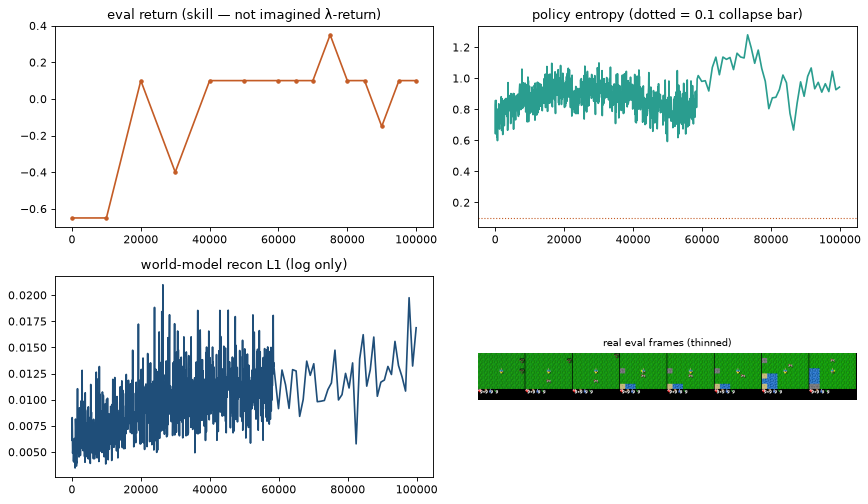

env 99840/100000  eval_ret=0.100  wm_l1=0.0169  ac_H=0.943
done checkpoints\m5_outer_loop\ckpt_final.pt


In [3]:
writer = SummaryWriter(log_dir=str(log_dir))
history: list[dict] = []
eval_history: list[dict] = []
metrics_path = results_dir / "train_metrics.json"
eval_path = results_dir / "eval_metrics.json"
if env_steps > 0 and metrics_path.is_file():
    prev = json.loads(metrics_path.read_text(encoding="utf-8"))
    history = [h for h in prev if int(h.get("env_steps", 0)) <= env_steps]
if env_steps > 0 and eval_path.is_file():
    prev_e = json.loads(eval_path.read_text(encoding="utf-8"))
    eval_history = [h for h in prev_e if int(h.get("env_steps", 0)) <= env_steps]

target = int(train["env_steps"])
collect_every = int(train["collect_every"])
eval_every = int(train["eval_every"])
log_every = int(train["log_every"])
dashboard_every = int(train.get("dashboard_every", 1000))
image_every = int(train["image_every"])
ckpt_every = int(train["checkpoint_every"])
start_mode = str(train.get("start_mode", "all"))
last_vis = None
last_eval_frames = None

def _thin_history(hist: list[dict], max_points: int = 800) -> list[dict]:
    if len(hist) <= max_points:
        return hist
    stride = max(1, len(hist) // max_points)
    return hist[::stride]


def _dashboard_strip(images: np.ndarray, keep_every: int = 2) -> np.ndarray:
    tiles = [images[i] for i in range(0, images.shape[0], keep_every)]
    return np.concatenate(tiles, axis=1)


def show_progress(hist, evals, vis_nchw, eval_frames, steps_per_sec=None):
    status = ""
    if hist:
        h = hist[-1]
        rate = f"  ({steps_per_sec:.2f} env/s)" if steps_per_sec else ""
        ev = evals[-1]["eval_return"] if evals else float("nan")
        status = (
            f"env {h['env_steps']}/{target}  eval_ret={ev:.3f}  "
            f"wm_l1={h.get('wm_recon_l1', float('nan')):.4f}  "
            f"ac_H={h.get('ac_entropy', float('nan')):.3f}{rate}"
        )
    try:
        clear_output(wait=False)
        plot_h = _thin_history(hist)
        fig = plt.figure(figsize=(11, 6.4), dpi=80)
        ax0 = fig.add_subplot(2, 2, 1)
        if evals:
            ax0.plot(
                [p["env_steps"] for p in evals],
                [p["eval_return"] for p in evals],
                color="#c45c26",
                marker=".",
            )
        ax0.set_title("eval return (skill — not imagined λ-return)")
        ax1 = fig.add_subplot(2, 2, 2)
        if plot_h:
            xs = [p["env_steps"] for p in plot_h]
            ax1.plot(xs, [p.get("ac_entropy", float("nan")) for p in plot_h], color="#2a9d8f")
        ax1.axhline(0.1, color="#c45c26", ls=":", lw=1)
        ax1.set_title("policy entropy (dotted = 0.1 collapse bar)")
        ax2 = fig.add_subplot(2, 2, 3)
        if plot_h:
            xs = [p["env_steps"] for p in plot_h]
            ax2.plot(xs, [p.get("wm_recon_l1", float("nan")) for p in plot_h], color="#1f4e79")
        ax2.set_title("world-model recon L1 (log only)")
        ax3 = fig.add_subplot(2, 2, 4)
        shown = False
        if eval_frames is not None:
            ax3.imshow(_dashboard_strip(eval_frames[:16]))
            ax3.set_title("real eval frames (thinned)", fontsize=9)
            shown = True
        elif vis_nchw is not None:
            seq = vis_nchw[0].detach().float().clamp(0, 1).permute(0, 2, 3, 1).cpu().numpy()
            ax3.imshow(_dashboard_strip((seq * 255).astype(np.uint8)))
            ax3.set_title("imagined decode (not skill)", fontsize=9)
            shown = True
        if shown:
            ax3.axis("off")
        fig.tight_layout()
        display(fig)
    except Exception as exc:
        print(f"[dashboard skipped: {type(exc).__name__}: {exc}]", flush=True)
    finally:
        plt.close("all")
    if status:
        print(status, flush=True)


def run_eval(step: int):
    global last_eval_frames
    result = evaluate_policy(
        eval_env,
        world_model,
        actor,
        device=device,
        n_episodes=int(train["eval_episodes"]),
        max_steps=int(train.get("eval_max_steps", train["max_episode_steps"])),
        amp_dtype=amp_dtype,
        seed=int(train.get("eval_seed", 100_000)),
    )
    log_eval(result, step, eval_history, writer)
    last_eval_frames = result.frames
    if result.frames is not None:
        save_eval_gif(result.frames, results_dir / f"eval_step_{step:06d}.gif")
    eval_path.write_text(json.dumps(eval_history), encoding="utf-8")


print(
    f"outer loop to {target} env steps on {device} "
    f"(start={env_steps}, remaining={target - env_steps})...",
    flush=True,
)
if device.type == "cuda":
    torch.cuda.reset_peak_memory_stats()

last_log_time = time.time()
last_log_env = env_steps
if env_steps == 0 or not eval_history:
    run_eval(env_steps)
    show_progress(history, eval_history, last_vis, last_eval_frames)

try:
    while env_steps < target:
        cycle = outer_cycle(
            collector,
            world_model,
            actor,
            critic,
            wm_optim,
            ac_optim,
            buffer,
            device=device,
            wm_train_cfg=wm_train_cfg,
            collect_every=collect_every,
            wm_updates=int(train["wm_updates"]),
            ac_updates=int(train["ac_updates"]),
            batch_size=int(train["batch_size"]),
            seq_len=int(train["seq_len"]),
            retnorm=retnorm,
            horizon=int(train["horizon"]),
            start_mode=start_mode,
            lam=float(train.get("lam", 0.95)),
            discount=float(train.get("discount", 0.997)),
            entropy_scale=float(train.get("entropy_scale", 3.0e-4)),
            amp_dtype=amp_dtype,
            scaler=scaler,
            wm_max_grad_norm=float(train.get("wm_max_grad_norm", 1000.0)),
            ac_max_grad_norm=float(train.get("ac_max_grad_norm", 100.0)),
        )
        prev_steps = env_steps
        env_steps += collect_every
        if cycle.wm_metrics is not None:
            wm_steps += int(train["wm_updates"])
        if cycle.ac_metrics is not None:
            ac_steps += int(train["ac_updates"])

        row = {"env_steps": env_steps, "wm_steps": wm_steps, "ac_steps": ac_steps}
        if cycle.wm_metrics:
            row.update({f"wm_{k}": v for k, v in cycle.wm_metrics.items()})
        if cycle.ac_metrics:
            row.update({f"ac_{k}": v for k, v in cycle.ac_metrics.items()})
        row["collect_reward"] = float(cycle.collect["reward_mean"])
        row["collect_entropy"] = float(cycle.collect["entropy"])

        sps = None
        do_log = (
            crossed_interval(prev_steps, env_steps, log_every)
            or env_steps <= collect_every
            or env_steps >= target
        )
        do_dash = crossed_interval(prev_steps, env_steps, dashboard_every) or env_steps <= collect_every
        if do_log:
            now = time.time()
            dt = max(now - last_log_time, 1e-6)
            sps = (env_steps - last_log_env) / dt
            last_log_time = now
            last_log_env = env_steps
            row["env_steps_per_sec"] = sps
            history.append(row)
            for k, v in row.items():
                if k != "env_steps" and isinstance(v, (int, float)) and np.isfinite(v):
                    writer.add_scalar(f"loop/{k}", float(v), env_steps)
            vram = vram_peak_gb()
            if vram:
                row["vram_alloc"] = vram[0]
            if not do_dash:
                ev = eval_history[-1]["eval_return"] if eval_history else float("nan")
                print(
                    f"env {env_steps}/{target}  eval_ret={ev:.3f}  "
                    f"wm_l1={row.get('wm_recon_l1', float('nan')):.4f}  "
                    f"ac_H={row.get('ac_entropy', float('nan')):.3f}  "
                    f"({sps:.2f} env/s)",
                    flush=True,
                )
        if do_dash:
            show_progress(history, eval_history, last_vis, last_eval_frames, steps_per_sec=sps)

        if crossed_interval(prev_steps, env_steps, eval_every):
            run_eval(env_steps)
            show_progress(history, eval_history, last_vis, last_eval_frames, steps_per_sec=sps)

        if cycle.rollout is not None and (
            crossed_interval(prev_steps, env_steps, image_every) or env_steps <= collect_every
        ):
            last_vis = decode_imagination(world_model, cycle.rollout.feat, max_starts=1)
            save_imagination_strip(last_vis, results_dir / f"imagine_step_{env_steps:06d}.png")
            save_imagination_gif(last_vis, results_dir / f"imagine_step_{env_steps:06d}.gif")

        if crossed_interval(prev_steps, env_steps, ckpt_every):
            payload = joint_payload(
                env_steps=env_steps,
                wm_steps=wm_steps,
                ac_steps=ac_steps,
                world_model=world_model,
                wm_optim=wm_optim,
                actor=actor,
                critic=critic,
                ac_optim=ac_optim,
                retnorm=retnorm,
                collect_seed=collector.next_seed,
            )
            save_checkpoint(ckpt_dir / f"ckpt_step_{env_steps}.pt", payload)
            save_checkpoint(ckpt_dir / "ckpt_latest.pt", payload)
            save_replay(buffer, replay_out)
            metrics_path.write_text(json.dumps(history), encoding="utf-8")
            eval_path.write_text(json.dumps(eval_history), encoding="utf-8")
            print(f"wrote {ckpt_dir / f'ckpt_step_{env_steps}.pt'}", flush=True)
            gc.collect()
finally:
    payload = joint_payload(
        env_steps=env_steps,
        wm_steps=wm_steps,
        ac_steps=ac_steps,
        world_model=world_model,
        wm_optim=wm_optim,
        actor=actor,
        critic=critic,
        ac_optim=ac_optim,
        retnorm=retnorm,
        collect_seed=collector.next_seed,
    )
    save_checkpoint(ckpt_dir / "ckpt_final.pt", payload)
    save_checkpoint(ckpt_dir / "ckpt_latest.pt", payload)
    save_replay(buffer, replay_out)
    metrics_path.write_text(json.dumps(history), encoding="utf-8")
    eval_path.write_text(json.dumps(eval_history), encoding="utf-8")
    writer.flush()
    writer.close()
    collect_env.close()
    eval_env.close()
    show_progress(history, eval_history, last_vis, last_eval_frames)
    print("done", ckpt_dir / "ckpt_final.pt")

## Exit criteria — M5 plumbing, not a Crafter score

- No NaNs; policy entropy above ~0.1; last eval return finite.
- At least two eval logs (start + one interval). First vs last eval mean is
  printed for you — 4-episode noise can go either way; that is a human gate.
- `ckpt_latest.pt` reloads (WM + actor + critic + retnorm + both optims + env_steps).

Geometric-mean achievement score is M6. Do not grind imagined λ-return.


In [4]:
assert len(history) >= 1, "need at least one logged cycle"
checks: list[tuple[str, bool, str]] = []

def _finite_keys(rows, keys):
    for row in rows:
        for k in keys:
            if k in row and isinstance(row[k], (int, float)) and not np.isfinite(row[k]):
                return False, k, row.get("env_steps")
    return True, "", None

ok_h, bad_k, bad_s = _finite_keys(history, ["wm_total", "ac_total", "ac_entropy", "collect_reward"])
checks.append(
    (
        "logged metrics are finite",
        ok_h,
        f"NaN in {bad_k} at env_steps={bad_s}",
    )
)
last = history[-1]
ent = float(last.get("ac_entropy", last.get("collect_entropy", 0.0)))
checks.append(
    (
        f"policy entropy is alive (last={ent:.3f} > 0.1)",
        ent > 0.1,
        "actor collapsed — check STE collect, not greedy logits",
    )
)
checks.append(
    (
        f"eval logs n={len(eval_history)} (>=2)",
        len(eval_history) >= 2,
        "need start eval + one interval (eval_every env steps)",
    )
)
if eval_history:
    last_ev = float(eval_history[-1]["eval_return"])
    checks.append(
        (
            f"last eval return is finite ({last_ev:.3f})",
            np.isfinite(last_ev),
            "eval return NaN",
        )
    )

reload_ok = False
ckpt_latest = ckpt_dir / "ckpt_latest.pt"
if ckpt_latest.is_file():
    payload = torch.load(ckpt_latest, weights_only=False, map_location="cpu")
    need = ["env_steps", "world_model", "actor", "critic", "wm_optim", "ac_optim", "retnorm"]
    reload_ok = all(k in payload for k in need)
checks.append(
    (
        "ckpt_latest has joint payload",
        reload_ok,
        "missing keys in ckpt_latest.pt",
    )
)

all_pass = True
print(f"env steps trained: {env_steps}")
print()
for msg, ok, hint in checks:
    status = "PASS" if ok else "FAIL"
    all_pass = all_pass and ok
    print(f"[{status}] {msg}")
    if not ok:
        print(f"       {hint}")
print()
if len(eval_history) >= 2:
    first_ev = float(eval_history[0]["eval_return"])
    last_ev = float(eval_history[-1]["eval_return"])
    print(
        f"eval return {first_ev:.3f} → {last_ev:.3f}  "
        f"(human gate: trends up? 4-episode noise is allowed)"
    )
print("RESULT:", "PASS — M5 plumbing looks healthy" if all_pass else "FAIL — see hints above")
print("GIF:", results_dir / f"eval_step_{env_steps:06d}.gif")

env steps trained: 100000

[PASS] logged metrics are finite
[PASS] policy entropy is alive (last=0.943 > 0.1)
[PASS] eval logs n=15 (>=2)
[PASS] last eval return is finite (0.100)
[PASS] ckpt_latest has joint payload

eval return -0.650 → 0.100  (human gate: trends up? 4-episode noise is allowed)
RESULT: PASS — M5 plumbing looks healthy
GIF: results\m5_outer_loop\eval_step_100000.gif
